# 🎓 소프트웨어랩 기말고사 — CNN
## 과제: MyLeNet5_2 모델 구현

**제출:** 모든 TODO 구현 → 전체 실행 → 스크린샷 → GitHub 업로드

---

### TODO 목록

| 번호 | 구현 대상 | 설명 | 난이도 |
|------|-----------|------|--------|
| ① | `MyLeNet5_2.__init__` | 아키텍처 표에 맞게 레이어 정의 | ⭐⭐ |
| ② | `MyLeNet5_2.forward` | 데이터 흐름 다이어그램대로 순전파 구현 | ⭐⭐⭐ |
| ③ | epochs 수정 | 원본 5 → **3**으로 변경 | ⭐ |
| ④ | 학번/이름 | STUDENT_ID, STUDENT_NAME 입력 | ⭐ |

> ⚠️ `# ===== 수정 금지 =====` 구역은 변경 금지

## 📐 구현할 모델: MyLeNet5_2 아키텍처

아래 표와 다이어그램을 참고하여 **MyLeNet5_2** 클래스를 구현하세요.

### 원본 MyLeNet5_1 vs 수정된 MyLeNet5_2 비교

| 레이어 | MyLeNet5_1 (원본) | **MyLeNet5_2 (구현 대상)** |
|--------|-------------------|---------------------------|
| conv_1 | Conv2d(1→**6**, k=5, pad=2) | Conv2d(1→**32**, k=5, pad=2) |
| maxpool_1 | MaxPool2d(2×2) | MaxPool2d(2×2) |
| conv_2 | Conv2d(**6**→**16**, k=5) | Conv2d(**32**→**64**, k=5) |
| maxpool_2 | MaxPool2d(2×2) | MaxPool2d(2×2) |
| conv_3 | Conv2d(**16**→**120**, k=5) | Conv2d(**64**→**256**, k=5) |
| fc_1 | Linear(**120**→**84**) | Linear(**256**→**128**) |
| fc_2 | Linear(**84**→10) | Linear(**128**→10) |
| batch_size | 16 | 16 *(동일)* |
| learning_rate | 0.01 | 0.01 *(동일)* |
| optimizer | Adadelta | Adadelta *(동일)* |
| **epochs** | **5** | **3** ← 변경 |


### 데이터 흐름 다이어그램

```
입력 [B, 1, 28, 28]
  │
  ▼
conv_1 (1→32채널, 5×5, pad=2) → ReLU → maxpool_1(2×2)
  │  출력: [B, 32, 14, 14]
  ▼
conv_2 (32→64채널, 5×5) → ReLU → maxpool_2(2×2)
  │  출력: [B, 64, 5, 5]
  ▼
conv_3 (64→256채널, 5×5) → Flatten → x.view(-1, 256)
  │  출력: [B, 256]
  ▼
fc_1 (256→128) → ReLU
  ▼
fc_2 (128→10)
  │
  ▼
출력 [B, 10]
```


## [1] 환경 설정

In [20]:
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt

use_cuda = torch.cuda.is_available()
device   = torch.device("cuda" if use_cuda else "cpu")
print(f"사용 디바이스: {device}")


사용 디바이스: cuda


## [2] 데이터 로딩 *(수정 금지)*

In [21]:
# ===== 수정 금지 =====
batch_size = 16
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

train_dataset = datasets.MNIST(
    './data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, **kwargs
)
test_dataset = datasets.MNIST(
    './data', train=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, **kwargs
)
print(f'학습: {len(train_dataset):,}개  |  테스트: {len(test_dataset):,}개')
# ===== 수정 금지 끝 =====


학습: 60,000개  |  테스트: 10,000개


## [3] TODO ①② — MyLeNet5_2 모델 정의

위의 아키텍처 표와 다이어그램을 보고 구현하세요.

In [22]:
class MyLeNet5_2(nn.Module):
    def __init__(self):
        super(MyLeNet5_2, self).__init__()

        # TODO ①-A : conv_1  →  Conv2d(1, 32, kernel_size=5, padding=2)
        self.conv_1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)   # ← 교체하세요

        # TODO ①-B : maxpool_1  →  MaxPool2d(kernel_size=(2,2), stride=2)
        self.maxpool_1 = nn.MaxPool2d(kernel_size=(2, 2), stride=2)   # ← 교체하세요

        # TODO ①-C : conv_2  →  Conv2d(32, 64, kernel_size=5)
        self.conv_2 = nn.Conv2d(32, 64, kernel_size=5)   # ← 교체하세요

        # TODO ①-D : maxpool_2  →  MaxPool2d(kernel_size=(2,2), stride=2)
        self.maxpool_2 = nn.MaxPool2d(kernel_size=(2, 2), stride=2)   # ← 교체하세요

        # TODO ①-E : conv_3  →  Conv2d(64, 256, kernel_size=5)
        self.conv_3 = nn.Conv2d(64, 256, kernel_size=5)   # ← 교체하세요

        # TODO ①-F : relu  →  nn.ReLU()
        self.relu = nn.ReLU()   # ← 교체하세요

        # TODO ①-G : fc_1  →  Linear(256, 128)
        self.fc_1 = nn.Linear(256, 128)   # ← 교체하세요

        # TODO ①-H : fc_2  →  Linear(128, 10)
        self.fc_2 = nn.Linear(128, 10)   # ← 교체하세요


    def forward(self, x):
        x = self.conv_1(x)
        x = self.relu(x)
        x = self.maxpool_1(x)
        x = self.conv_2(x)
        x = self.relu(x)
        x = self.maxpool_2(x)
        x = self.conv_3(x)
        x = x.view(-1, 256)  # flatten
        x = self.fc_1(x)
        x = self.relu(x)
        res = self.fc_2(x)
        return res
        # TODO ② : 순전파 구현
        pass   # ← 이 줄을 지우고 구현하세요

# ===== 수정 금지 =====
model_test = MyLeNet5_2()
print(model_test)
total_params = sum(p.numel() for p in model_test.parameters())
print(f"파라미터 수: {total_params:,}개")
# ===== 수정 금지 끝 =====


MyLeNet5_2(
  (conv_1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool_1): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (maxpool_2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_3): Conv2d(64, 256, kernel_size=(5, 5), stride=(1, 1))
  (relu): ReLU()
  (fc_1): Linear(in_features=256, out_features=128, bias=True)
  (fc_2): Linear(in_features=128, out_features=10, bias=True)
)
파라미터 수: 496,138개


## [4] TODO ③④ — 하이퍼파라미터 & 학번 입력

In [23]:
# TODO ③ : epochs 수정
epochs        = 3
learning_rate = 0.01

# TODO ④ : 학번/이름 (필수)
STUDENT_ID   = "2023103987" #e.g., 20201111111
STUDENT_NAME = "박성준" #e.g., Hong Gil Dong

# ===== 수정 금지 =====
model         = MyLeNet5_2().to(device)
optimizer     = optim.Adadelta(model.parameters(), lr=learning_rate)
scheduler     = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)
loss_function = nn.CrossEntropyLoss()

print(f"학번: {STUDENT_ID}  이름: {STUDENT_NAME}")
print(f"epochs={epochs}  lr={learning_rate}  optimizer=Adadelta")
# ===== 수정 금지 끝 =====


학번: 2023103987  이름: 박성준
epochs=3  lr=0.01  optimizer=Adadelta


## [5] 학습 & 테스트 함수 *(수정 금지)*

In [24]:
# ===== 수정 금지 =====
def train(model, device, train_loader, optimizer, loss_function, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss   = loss_function(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 1000 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

def test(model, device, test_loader, loss_function):
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output    = model(data)
            test_loss += loss_function(output, target).item()
            pred       = output.argmax(dim=1, keepdim=True)
            correct   += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    acc = 100. * correct / len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset), acc))
    return acc
# ===== 수정 금지 끝 =====


## [6] 학습 실행 *(수정 금지 — 스크린샷 캡처)*

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.354611
Train Epoch: 0 [16000/60000 (27%)]	Loss: 0.373094
Train Epoch: 0 [32000/60000 (53%)]	Loss: 0.365290
Train Epoch: 0 [48000/60000 (80%)]	Loss: 0.125050

Test set: Average loss: 0.0097, Accuracy: 9557/10000 (95.57%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.061348
Train Epoch: 1 [16000/60000 (27%)]	Loss: 0.480915
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.261263
Train Epoch: 1 [48000/60000 (80%)]	Loss: 0.069388

Test set: Average loss: 0.0087, Accuracy: 9578/10000 (95.78%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.058433
Train Epoch: 2 [16000/60000 (27%)]	Loss: 0.410230
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.108607
Train Epoch: 2 [48000/60000 (80%)]	Loss: 0.111724

Test set: Average loss: 0.0086, Accuracy: 9595/10000 (95.95%)

  학번: 2023103987  이름: 박성준
  최종 Test Accuracy: 95.95%


/tmp/ipykernel_3423/2497278399.py:18: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  plt.grid(True, alpha=0.4); plt.tight_layout()
/tmp/ipykernel_3423/2497278399.py:18: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.grid(True, alpha=0.4); plt.tight_layout()
/tmp/ipykernel_3423/2497278399.py:18: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.grid(True, alpha=0.4); plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from 

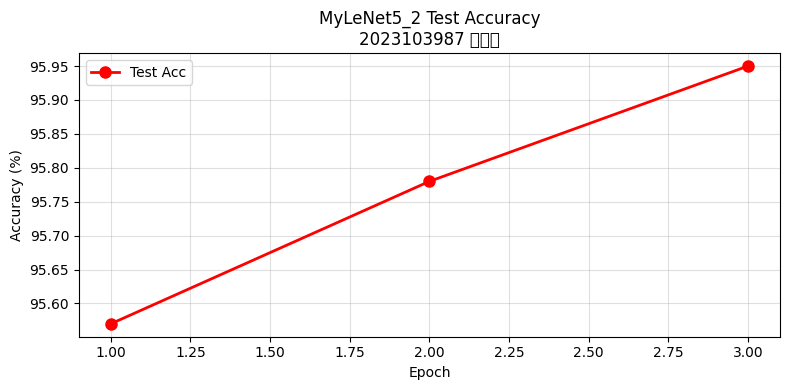

In [25]:
# ===== 수정 금지 =====
test_accs = []
for epoch in range(epochs):
    train(model, device, train_loader, optimizer, loss_function, epoch)
    acc = test(model, device, test_loader, loss_function)
    test_accs.append(acc)
    scheduler.step()

print("=" * 50)
print(f"  학번: {STUDENT_ID}  이름: {STUDENT_NAME}")
print(f"  최종 Test Accuracy: {test_accs[-1]:.2f}%")
print("=" * 50)

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), test_accs, 'r-o', markersize=8, linewidth=2)
plt.title(f'MyLeNet5_2 Test Accuracy\n{STUDENT_ID} {STUDENT_NAME}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(['Test Acc'])
plt.grid(True, alpha=0.4); plt.tight_layout()
# ===== 수정 금지 끝 =====
